1. Create Toy Healthcare Dataset
🎯 What this does

Simulates patients with subtle subgroups (like disease subtypes)

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

# 200 patients, 10 features
group1 = np.random.normal(0, 1, (100, 10))     # healthy-ish
group2 = np.random.normal(3, 1, (100, 10))     # higher risk

data = np.vstack([group1, group2])

df = pd.DataFrame(data, columns=[f"feature_{i}" for i in range(10)])

Pattern
np.random.normal(mean, std, shape)
np.vstack([group1, group2])

2. Standardize Data

👉 Always required for distance-based methods

2. Standardize Data

👉 Always required for distance-based methods

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

3. Apply PCA (Pre-step)

👉 Best practice: reduce noise before t-SNE/UMAP

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
pca_data = pca.fit_transform(scaled_data)

4. Apply t-SNE (Local Structure)
🎯 What this does

Finds small clusters / subtle subgroups

In [8]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(pca_data)

Pattern
TSNE(n_components=2, perplexity=30)
fit_transform(data)

5. Visualize t-SNE

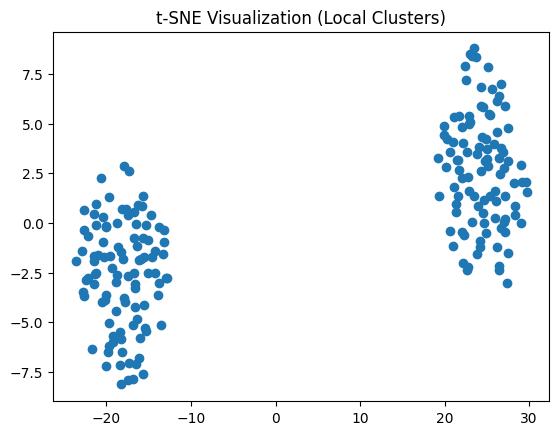

In [9]:
import matplotlib.pyplot as plt

plt.scatter(tsne_result[:, 0], tsne_result[:, 1])
plt.title("t-SNE Visualization (Local Clusters)")
plt.show()

What you’ll observe
Very tight, well-separated clusters
Great for:
Disease subtypes
Cell types (genomics)
Hidden small groups

6. Apply UMAP (Local + Global)

In [10]:
import umap

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = umap_model.fit_transform(pca_data)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Pattern
UMAP(n_neighbors=15, min_dist=0.1)
fit_transform(data)

7. Visualize UMAP

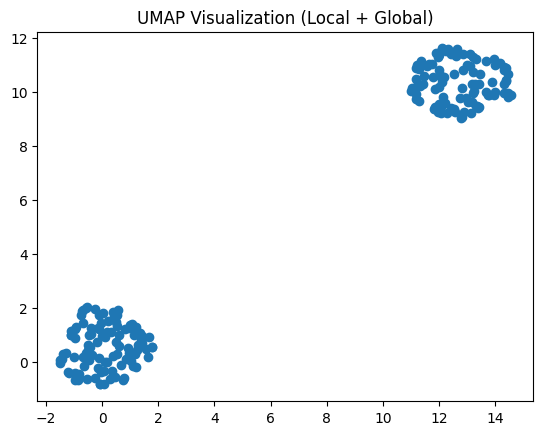

In [11]:
plt.scatter(umap_result[:, 0], umap_result[:, 1])
plt.title("UMAP Visualization (Local + Global)")
plt.show()

What you’ll observe
Clusters are visible
BUT also:
Distance between clusters makes sense
Shows gradual transitions

t-SNE vs UMAP (Same Data Insight)
🔴 t-SNE

👉 Use when:

You want to find small hidden groups
You don’t care about global distance

Example:

Cancer subtypes
Immune cell types
Rare disease clusters

👉 Behavior:

Clusters look very separated
But distance between clusters = ❌ not meaningful

UMAP

👉 Use when:

You want structure + relationships
You may use it in pipeline (production)

Example:

Disease progression (mild → severe)
Patient risk spectrum
Population health segmentation

👉 Behavior:

Preserves:
Local clusters ✅
Global structure ✅
🔥 Key Difference (Most Important)
t-SNE → "Who is similar?"
UMAP → "Who is similar AND how groups relate?"
🧠 Real Healthcare Decision Rule
Use t-SNE when:
Research / exploration
Looking for hidden subtypes
Visualization only
Use UMAP when:
You want:
Scalable method
Consistent results
Ability to transform new patients
⚠️ Important Beginner Mistake

❌ Don’t use t-SNE output for modeling
✅ Use it only for visualization

✔ UMAP can sometimes be used in pipelines

🧠 Final Intuition

Think of it like this:

t-SNE = 🔬 microscope (zoom into details)
UMAP = 🗺️ map (shows landscape + relationships)